# 05 · El azar: ¿quién tuvo suerte?

**Objetivo:** estudiar el ~75 % de azar que encontró la fase 4. ¿Qué equipos sacaron más (o menos) puntos de los que merecían? ¿Es realmente suerte, o es habilidad que el xG no capta?

**Decisiones de esta fase**

| Decisión | Elección | Motivo |
|---|---|---|
| Qué es "suerte" | **Puntos − puntos esperados** (medida principal) y **goles − xG** separando ataque y defensa (origen) | Mide el tramo de azar: dadas las ocasiones que hubo, ¿sumó más o menos de lo que tocaba? |
| ¿Suerte o habilidad? | **Persistencia entre la 1ª y la 2ª vuelta**, **regresión a la media** en la temporada siguiente, y **ataque y defensa por separado** | La suerte no se repite; la habilidad sí |
| Sorpresas | Probabilidad que el modelo elegido en la fase 4 (Elo + forma) daba al resultado ocurrido, entrenado con todas las temporadas | Lista descriptiva de toda la década; con 3 variables el sobreajuste es despreciable |
| ¿Merecida o con suerte? | Se cruza cada sorpresa con el xG del partido: ¿creó el ganador inesperado más ocasiones? | Conecta con el reparto juego / azar de la fase 4 |
| Suerte persistente | Equipos con ≥ 5 temporadas; prueba t por equipo y medida frente a la **media de la liga** de cada temporada; corrección de Benjamini-Hochberg (FDR 10 %) | ~90 comprobaciones: sin corrección, alguna saldría por azar |
| Causantes | **Ataque:** jugadores (bloque `players` de Understat, goles sin penaltis − xG sin penaltis). **Defensa:** hipótesis etiquetadas, sin datos de porteros | Usar datos donde existen; no presentar opiniones como resultados |
| Anomalías | *Isolation Forest* sobre las estadísticas de los dos equipos por partido; sin umbral, se revisan los 20 más anómalos; comprobación con las faltas sospechosas de la fase 1 | Cualquier umbral fijo sería arbitrario |
| Datos | 2014/15–2025/26, todas las temporadas (incluidas las de test) | Es un análisis **descriptivo**, no la evaluación de un modelo |

**Limitación de partida:** los puntos esperados y el xG son **modelos de Understat**, que suponen un tirador y un portero "medios". Rendir por encima del xG puede ser suerte o habilidad; la sección 3 lo comprueba.

## 0. Preparación

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "reports" / "figures"

con = duckdb.connect(config={"threads": 1})   # un hilo: las sumas siempre en el mismo orden (resultados idénticos byte a byte)
con.sql(f"CREATE VIEW partidos_equipo AS SELECT * FROM read_csv('{(PROCESSED / 'partidos_equipo.csv').as_posix()}')")

SERIE, TINTA, TINTA_2, FONDO, REJILLA = "#2a78d6", "#0b0b0b", "#52514e", "#fcfcfb", "#e4e3df"
NARANJA, GRIS = "#eb6834", "#c9c8c3"

## 1. La suerte de cada equipo-temporada

| Medida | Cálculo | Positivo significa… |
|---|---|---|
| **Suerte en puntos** | puntos − puntos esperados | sumó más de lo que merecían sus ocasiones |
| **Suerte en ataque** (definición) | goles a favor − xG a favor | marcó más de lo esperado |
| **Suerte en defensa** (portería) | xG en contra − goles en contra | encajó menos de lo esperado |

Los **puntos esperados** de Understat son la media de puntos que se obtendría si el partido se repitiera muchas veces con las mismas ocasiones.

In [2]:
suerte = con.sql("""
SELECT temporada, equipo,
       count(*)                                    AS partidos,
       sum(puntos)                                 AS puntos,
       round(sum(puntos_esperados), 1)             AS puntos_esperados,
       sum(puntos) - sum(puntos_esperados)         AS suerte_puntos,
       sum(goles_favor) - sum(xg_favor)            AS suerte_ataque,
       sum(xg_contra) - sum(goles_contra)          AS suerte_defensa
FROM partidos_equipo
WHERE temporada >= '2014-15'
GROUP BY temporada, equipo
ORDER BY temporada, puntos DESC, equipo        -- desempate: orden reproducible
""").df()
assert len(suerte) == 240 and (suerte.partidos == 38).all()
suerte[["suerte_puntos", "suerte_ataque", "suerte_defensa"]].describe().round(2)

,suerte_puntos,suerte_ataque,suerte_defensa
count,240.00,240.00,240.00
mean,-0.40,-1.63,1.63
std,7.71,7.28,7.49
min,-20.16,-18.98,-29.18
25%,-5.65,-6.62,-3.66
50%,-0.38,-2.28,1.95
75%,5.01,2.83,7.52
max,19.59,22.45,15.93


In [3]:
# Los 10 equipos-temporada con más suerte y los 10 con menos
columnas = ["temporada", "equipo", "puntos", "puntos_esperados", "suerte_puntos", "suerte_ataque", "suerte_defensa"]
ranking = suerte.sort_values("suerte_puntos", ascending=False)[columnas].round(1)
pd.concat([ranking.head(10).assign(grupo="más suerte"), ranking.tail(10).iloc[::-1].assign(grupo="menos suerte")])

,temporada,equipo,puntos,puntos_esperados,suerte_puntos,suerte_ataque,suerte_defensa,grupo
120,2020-21,Atlético de Madrid,86.0,66.4,19.6,9.3,10.7,más suerte
180,2023-24,Real Madrid,95.0,77.4,17.6,6.1,13.3,más suerte
61,2017-18,Atlético de Madrid,79.0,61.6,17.4,7.7,13.5,más suerte
182,2023-24,Girona,81.0,63.8,17.2,7.0,15.9,más suerte
81,2018-19,Atlético de Madrid,76.0,59.4,16.6,3.1,12.4,más suerte
22,2015-16,Atlético de Madrid,88.0,72.3,15.7,8.1,9.8,más suerte
220,2025-26,Barcelona,94.0,79.1,14.9,-4.7,14.7,más suerte
63,2017-18,Valencia,73.0,58.2,14.8,7.2,9.9,más suerte
121,2020-21,Real Madrid,84.0,70.0,14.0,1.9,10.7,más suerte
60,2017-18,Barcelona,93.0,79.4,13.6,8.5,12.6,más suerte


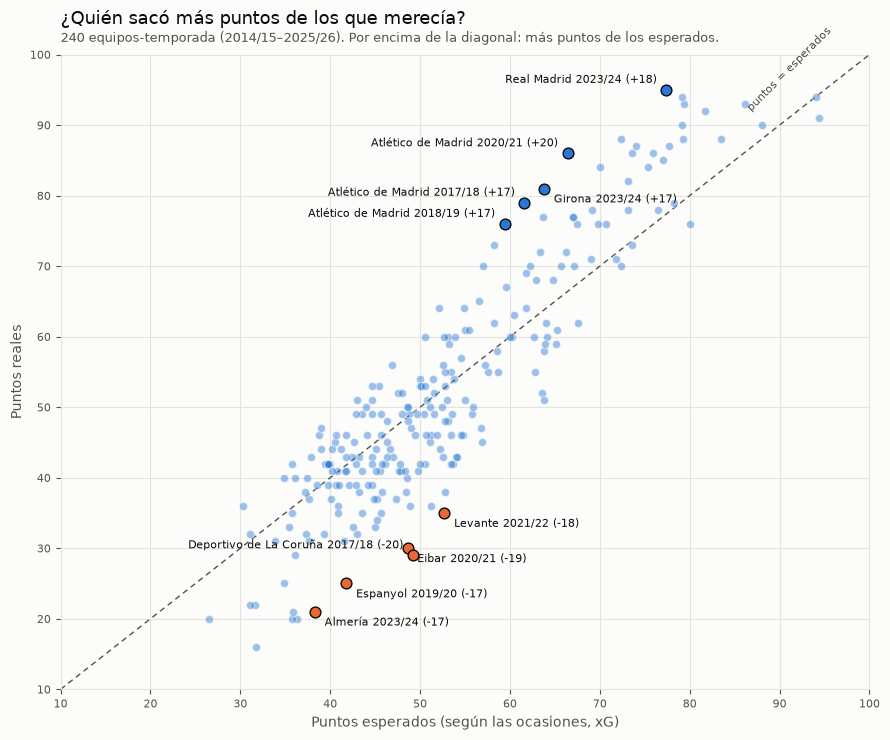

In [4]:
fig, ax = plt.subplots(figsize=(9, 7.5), facecolor=FONDO)
lim = (10, 100)
ax.plot(lim, lim, color=TINTA_2, linewidth=1, linestyle=(0, (4, 3)), zorder=1)
ax.text(96, 92, "puntos = esperados", fontsize=8, color=TINTA_2, ha="right", rotation=45)
ax.scatter(suerte.puntos_esperados, suerte.puntos, s=34, color=SERIE, alpha=0.45, edgecolor=FONDO, linewidth=0.8, zorder=2)

extremos = pd.concat([ranking.head(5), ranking.tail(5)])
colocadas = []
for _, f in extremos.iterrows():
    color = SERIE if f.suerte_puntos > 0 else NARANJA
    ax.scatter(f.puntos_esperados, f.puntos, s=60, color=color, edgecolor=TINTA, linewidth=1, zorder=3)
    cerca = any(abs(f.puntos_esperados - x) < 3 and abs(f.puntos - y) < 3 for x, y in colocadas)
    a_la_izquierda = (f.suerte_puntos > 0) != cerca           # si hay otra etiqueta cerca, cambia de lado
    ax.annotate(f"{f.equipo} {f.temporada.replace('-', '/')} ({f.suerte_puntos:+.0f})", (f.puntos_esperados, f.puntos),
                xytext=(-7, 5) if a_la_izquierda else (7, -10), textcoords="offset points",
                ha="right" if a_la_izquierda else "left", fontsize=8, color=TINTA)
    colocadas.append((f.puntos_esperados, f.puntos))

ax.set_xlim(*lim); ax.set_ylim(*lim)
ax.set_xlabel("Puntos esperados (según las ocasiones, xG)", color=TINTA_2)
ax.set_ylabel("Puntos reales", color=TINTA_2)
ax.set_facecolor(FONDO)
ax.grid(color=REJILLA, linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors=TINTA_2, labelsize=8)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)
for lado in ("left", "bottom"):
    ax.spines[lado].set_color(REJILLA)
ax.set_title("¿Quién sacó más puntos de los que merecía?", loc="left", fontsize=13, color=TINTA, pad=22)
ax.text(0, 1.02, "240 equipos-temporada (2014/15–2025/26). Por encima de la diagonal: más puntos de los esperados.",
        transform=ax.transAxes, fontsize=9, color=TINTA_2)
fig.tight_layout()
fig.savefig(FIGURES / "05_puntos_vs_esperados.png", dpi=150, facecolor=FONDO)
plt.show()

### ¿Suerte o Oblak? El caso del Atlético

El Atlético aparece **cuatro veces** entre los seis equipos-temporada con más suerte, y casi siempre por la **defensa** (encaja bastante menos de lo que dice su xG en contra). Algo que se repite tanto no parece azar. Lo miramos temporada a temporada:

In [5]:
(suerte[suerte.equipo == "Atlético de Madrid"]
 .set_index("temporada")[["puntos", "puntos_esperados", "suerte_puntos", "suerte_ataque", "suerte_defensa"]]
 .round(1))

,puntos,puntos_esperados,suerte_puntos,suerte_ataque,suerte_defensa
temporada,,,,,
2014-15,78.0,73.1,4.9,10.0,0.1
2015-16,88.0,72.3,15.7,8.1,9.8
2016-17,78.0,69.1,8.9,9.3,4.3
2017-18,79.0,61.6,17.4,7.7,13.5
2018-19,76.0,59.4,16.6,3.1,12.4
2019-20,70.0,72.4,-2.4,-7.7,4.5
2020-21,86.0,66.4,19.6,9.3,10.7
2021-22,71.0,69.0,2.0,5.6,-7.2
2022-23,77.0,67.0,10.0,1.3,10.2


El Atlético suma más puntos de los esperados en **11 de sus 12 temporadas**, y encaja menos goles de los esperados en **10 de 12**. Algo tan repetido **sugiere** una habilidad que el xG no capta. Hipótesis (no verificadas con datos): un portero por encima de la media (el xG supone un portero medio, y el Atlético ha tenido a Jan Oblak casi todo el periodo) o un sistema defensivo que dificulta el tiro. ⚠️ La sección 6 lo somete a una prueba más exigente (comparando con la media de la liga y corrigiendo por comparaciones múltiples): la persistencia en **puntos** se confirma; la de **defensa**, no llega a ser significativa. La sección 3 comprueba si este patrón es general.

**Un detalle del propio xG:** la suerte media en ataque es −1,6 goles por equipo y temporada, y en defensa +1,6. Es decir, en LaLiga se marcan en total algo menos goles de los que predice el xG de Understat (≈ 0,04 por equipo y partido). Es un pequeño sesgo del modelo de xG, y afecta a todos los equipos por igual.

## 2. ¿De dónde viene la suerte?

La suerte en puntos se descompone (aproximadamente) en suerte en ataque y en defensa. ¿Cuánto se relaciona cada una con la suerte en puntos?

In [6]:
suerte[["suerte_puntos", "suerte_ataque", "suerte_defensa"]].corr().round(2)

,suerte_puntos,suerte_ataque,suerte_defensa
suerte_puntos,1.00,0.54,0.53
suerte_ataque,0.54,1.00,-0.14
suerte_defensa,0.53,-0.14,1.00


## 3. ¿Suerte o habilidad? Persistencia entre la 1ª y la 2ª vuelta

**Idea:** la suerte no se repite; la habilidad sí. Si un equipo que "tiene suerte" en la primera vuelta también la tiene en la segunda, no es suerte: es algo del equipo (un gran delantero, un gran portero) que el modelo de xG no capta.

Para cada equipo-temporada calculamos cada medida por separado en la primera vuelta (partidos 1-19) y en la segunda (20-38), y medimos su correlación. Como **contraste**, hacemos lo mismo con medidas de **rendimiento** (puntos esperados, xG a favor): esas deberían repetirse, porque reflejan la calidad del equipo.

El intervalo de confianza del 95 % se calcula con la transformación de Fisher (n = 240 parejas).

In [7]:
mitades = con.sql("""
WITH numerados AS (
    SELECT *, row_number() OVER (PARTITION BY temporada, equipo ORDER BY fecha, id_partido) AS n
    FROM partidos_equipo WHERE temporada >= '2014-15'
)
SELECT temporada, equipo, CASE WHEN n <= 19 THEN 1 ELSE 2 END AS vuelta,
       sum(puntos) - sum(puntos_esperados)   AS suerte_puntos,
       sum(goles_favor) - sum(xg_favor)      AS suerte_ataque,
       sum(xg_contra) - sum(goles_contra)    AS suerte_defensa,
       sum(puntos_esperados)                 AS puntos_esperados,
       sum(xg_favor)                         AS xg_favor,
       sum(xg_contra)                        AS xg_contra
FROM numerados
GROUP BY temporada, equipo, vuelta
""").df()
v1 = mitades[mitades.vuelta == 1].set_index(["temporada", "equipo"])
v2 = mitades[mitades.vuelta == 2].set_index(["temporada", "equipo"]).loc[v1.index]


def correlacion_ic(x, y):
    r = np.corrcoef(x, y)[0, 1]
    z, se = np.arctanh(r), 1 / np.sqrt(len(x) - 3)
    return r, np.tanh(z - 1.96 * se), np.tanh(z + 1.96 * se)


MEDIDAS = {
    "suerte_puntos": ("Suerte en puntos", "suerte"),
    "suerte_ataque": ("Suerte en ataque (definición)", "suerte"),
    "suerte_defensa": ("Suerte en defensa (portería)", "suerte"),
    "puntos_esperados": ("Puntos esperados", "rendimiento"),
    "xg_favor": ("xG a favor", "rendimiento"),
    "xg_contra": ("xG en contra", "rendimiento"),
}
persistencia = pd.DataFrame([
    {"medida": nombre, "tipo": tipo, **dict(zip(["correlación 1ª-2ª vuelta", "IC 95 % inferior", "IC 95 % superior"],
                                                correlacion_ic(v1[col], v2[col])))}
    for col, (nombre, tipo) in MEDIDAS.items()])
persistencia.round(3)

,medida,tipo,correlación 1ª-2ª vuelta,IC 95 % inferior,IC 95 % superior
0,Suerte en puntos,suerte,0.157,0.031,0.278
1,Suerte en ataque (definición),suerte,0.150,0.024,0.272
2,Suerte en defensa (portería),suerte,0.306,0.186,0.416
3,Puntos esperados,rendimiento,0.794,0.741,0.836
4,xG a favor,rendimiento,0.821,0.775,0.858
5,xG en contra,rendimiento,0.615,0.530,0.688


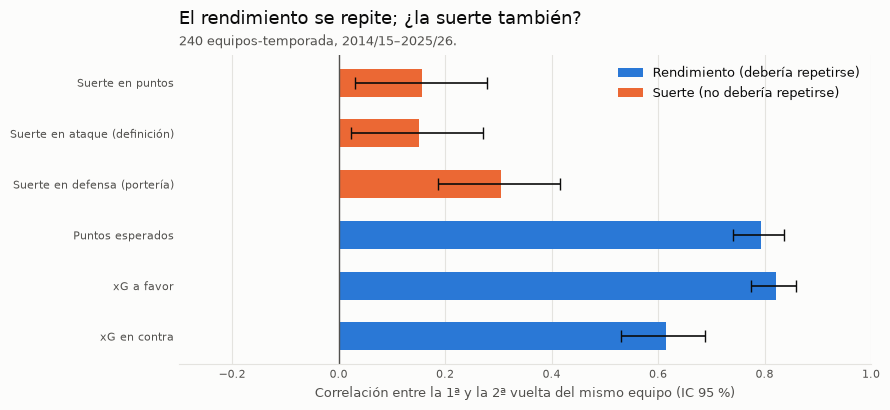

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.2), facecolor=FONDO)
orden = persistencia.iloc[::-1].reset_index(drop=True)
for i, f in orden.iterrows():
    color = SERIE if f.tipo == "rendimiento" else NARANJA
    ax.barh(i, f["correlación 1ª-2ª vuelta"], height=0.55, color=color)
    ax.errorbar(f["correlación 1ª-2ª vuelta"], i, color=TINTA, capsize=4, linewidth=1.2,
                xerr=[[f["correlación 1ª-2ª vuelta"] - f["IC 95 % inferior"]], [f["IC 95 % superior"] - f["correlación 1ª-2ª vuelta"]]])
ax.set_yticks(range(len(orden)), orden.medida, fontsize=9, color=TINTA)
ax.axvline(0, color=TINTA_2, linewidth=1)
ax.set_xlim(-0.3, 1)
ax.set_xlabel("Correlación entre la 1ª y la 2ª vuelta del mismo equipo (IC 95 %)", color=TINTA_2, fontsize=9)
for tipo, color in (("Rendimiento (debería repetirse)", SERIE), ("Suerte (no debería repetirse)", NARANJA)):
    ax.barh(np.nan, 0, color=color, label=tipo)
ax.legend(loc="upper right", frameon=False, fontsize=9, labelcolor=TINTA)
ax.set_facecolor(FONDO)
ax.grid(axis="x", color=REJILLA, linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors=TINTA_2, labelsize=8, length=0)
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)
ax.spines["bottom"].set_color(REJILLA)
ax.set_title("El rendimiento se repite; ¿la suerte también?", loc="left", fontsize=13, color=TINTA, pad=22)
ax.text(0, 1.03, "240 equipos-temporada, 2014/15–2025/26.", transform=ax.transAxes, fontsize=9, color=TINTA_2)
fig.tight_layout()
fig.savefig(FIGURES / "05_suerte_o_habilidad.png", dpi=150, facecolor=FONDO)
plt.show()

## 4. Regresión a la media: ¿los afortunados empeoran al año siguiente?

Si la suerte en puntos no se repite, un equipo con mucha suerte debería **perder** puntos al año siguiente (y uno con mala suerte, ganarlos), aunque su calidad no cambie.

Para cada equipo-temporada con **temporada siguiente en Primera** comparamos la variación de puntos con su suerte de este año. Como **control**, hacemos lo mismo con la variación de **puntos esperados**: si la suerte es azar, no debería anticipar cambios en el rendimiento real.

⚠️ **Sesgo de supervivencia:** los equipos que descienden no tienen temporada siguiente, y los desafortunados descienden más. Contamos cuántos se pierden en cada grupo.

In [9]:
s = suerte.sort_values(["equipo", "temporada"]).copy()
temporadas = sorted(s.temporada.unique())
siguiente = {t: temporadas[i + 1] for i, t in enumerate(temporadas[:-1])}
s["temporada_siguiente"] = s.temporada.map(siguiente)
s = s.merge(s[["temporada", "equipo", "puntos", "puntos_esperados"]].rename(
        columns={"temporada": "temporada_siguiente", "puntos": "puntos_sig", "puntos_esperados": "esperados_sig"}),
    on=["temporada_siguiente", "equipo"], how="left")
s = s[s.temporada_siguiente.notna()]                     # 2025-26 no tiene siguiente en los datos
s["cuartil_suerte"] = pd.qcut(s.suerte_puntos, 4, labels=["1 · menos suerte", "2", "3", "4 · más suerte"])

supervivencia = s.groupby("cuartil_suerte", observed=True).agg(
    equipos=("equipo", "size"), siguen_en_primera=("puntos_sig", lambda x: x.notna().sum()))
supervivencia["descienden"] = supervivencia.equipos - supervivencia.siguen_en_primera
supervivencia

,equipos,siguen_en_primera,descienden
cuartil_suerte,,,
1 · menos suerte,55,31,24
2,55,51,4
3,55,51,4
4 · más suerte,55,54,1


In [10]:
c = s[s.puntos_sig.notna()].copy()
c["cambio_puntos"] = c.puntos_sig - c.puntos
c["cambio_esperados"] = c.esperados_sig - c.puntos_esperados

pendiente_puntos = np.polyfit(c.suerte_puntos, c.cambio_puntos, 1)[0]
pendiente_control = np.polyfit(c.suerte_puntos, c.cambio_esperados, 1)[0]
print(f"{len(c)} equipos-temporada con temporada siguiente en Primera")
print(f"Por cada punto de suerte este año, el año siguiente: {pendiente_puntos:+.2f} puntos reales "
      f"y {pendiente_control:+.2f} puntos esperados (control)")

c.groupby("cuartil_suerte", observed=True).agg(
    suerte_media=("suerte_puntos", "mean"),
    cambio_puntos_medio=("cambio_puntos", "mean"),
    cambio_esperados_medio=("cambio_esperados", "mean"),
    equipos=("equipo", "size")).round(1)

187 equipos-temporada con temporada siguiente en Primera
Por cada punto de suerte este año, el año siguiente: -0.73 puntos reales y +0.02 puntos esperados (control)


,suerte_media,cambio_puntos_medio,cambio_esperados_medio,equipos
cuartil_suerte,,,,
1 · menos suerte,-8.8,7.4,-0.3,31
2,-2.7,0.3,-0.8,51
3,2.2,-2.8,-0.0,51
4 · más suerte,9.4,-7.9,-0.8,54


### Conclusiones: ¿suerte o habilidad?

**1. La mayor parte de la "suerte" es suerte.** Los puntos esperados, el xG a favor y el xG en contra de un equipo se repiten mucho entre la primera y la segunda vuelta (0,62–0,82): son **calidad**. La diferencia entre puntos reales y esperados se repite muy poco (0,16): es sobre todo **azar**.

**2. Pero no toda.** Esa correlación de 0,16 es pequeña pero distinta de cero (IC 0,03–0,28), y en **defensa** es claramente mayor (0,31, IC 0,19–0,42). Encajar menos de lo que dice el xG tiene un componente **persistente**, compatible con habilidad que el xG no mide (un buen portero, un sistema que dificulta el tiro); con estos datos no se puede saber cuál. (Por equipos, ver la sección 6: con corrección por comparaciones múltiples, el caso persistente en defensa es el Real Madrid.)

**3. La suerte se devuelve al año siguiente.** Por cada punto de suerte de una temporada, el equipo suma **0,73 puntos menos** la temporada siguiente, mientras que sus puntos esperados no cambian (+0,02, control). Los equipos del cuartil con más suerte pierden de media 7,9 puntos al año siguiente; los del cuartil con menos suerte ganan 7,4.

⚠️ **Sesgo de supervivencia en el punto 3:** del cuartil con menos suerte, **24 de 55** equipos descendieron y no tienen temporada siguiente; del cuartil con más suerte, solo 1. La mala suerte manda a Segunda, y esos equipos desaparecen de la comparación. La mejora de los desafortunados se mide solo con los que sobrevivieron.

**Lección para un director deportivo:** no juzgues una temporada por los puntos, sino por los puntos esperados. Una temporada con mucha suerte anticipa una caída; una con mala suerte, una mejora (si el equipo sobrevive a ella).

## 5. Las mayores sorpresas de la década

**Probabilidades:** el modelo elegido en la fase 4 (regresión ordinal con Elo + forma en puntos + forma en xG), entrenado con **todas** las temporadas 2014/15–2025/26. Es una lista **descriptiva**: cada partido entra en su propio entrenamiento, pero con 3 variables y ~4.000 partidos el efecto es despreciable.

Se usa `OrderedModel` de statsmodels, que en la fase 4 dio las mismas probabilidades que nuestra implementación (sin regularización; la validación eligió λ ≈ 0 para este modelo).

Se aplican las mismas exclusiones que en la fase 4 para este modelo: ascendidos en sus 5 primeros partidos y equipos sin 5 partidos de forma en xG.

**Sorpresa** = probabilidad que el modelo daba al resultado que ocurrió. Cuanto más baja, mayor la sorpresa.

In [11]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

con.sql(f"CREATE OR REPLACE VIEW forma_elo AS SELECT * FROM read_csv('{(PROCESSED / 'forma_elo.csv').as_posix()}')")
con.sql(f"CREATE OR REPLACE VIEW partidos AS SELECT * FROM read_csv('{(PROCESSED / 'partidos.csv').as_posix()}')")

pm = con.sql("""
SELECT p.id_partido, p.temporada, p.fecha, p.local, p.visitante, p.goles_local, p.goles_visitante, p.resultado,
       p.xg_local, p.xg_visitante,
       l.elo_antes - v.elo_antes                   AS elo_dif,
       l.forma_puntos - v.forma_puntos             AS forma_puntos_dif,
       l.forma_xg_dif - v.forma_xg_dif             AS forma_xg_dif_dif
FROM partidos p
JOIN forma_elo l ON l.id_partido = p.id_partido AND l.equipo = p.local
JOIN forma_elo v ON v.id_partido = p.id_partido AND v.equipo = p.visitante
WHERE p.temporada >= '2014-15'
  AND NOT l.periodo_ascenso AND NOT v.periodo_ascenso
  AND l.n_forma_xg = 5 AND v.n_forma_xg = 5
""").df()
pm["y"] = pm.resultado.map({"2": 0, "X": 1, "1": 2})
VARS = ["elo_dif", "forma_puntos_dif", "forma_xg_dif_dif"]

modelo = OrderedModel(pm.y.to_numpy(), pm[VARS].to_numpy(), distr="logit").fit(method="bfgs", disp=False)
prob = modelo.predict(pm[VARS].to_numpy())
pm[["p_visitante", "p_empate", "p_local"]] = prob
pm["p_resultado"] = prob[np.arange(len(pm)), pm.y.to_numpy()]
print(f"{len(pm)} partidos · probabilidad media asignada al resultado ocurrido: {pm.p_resultado.mean():.3f}")

4355 partidos · probabilidad media asignada al resultado ocurrido: 0.426


**¿Merecida o con suerte?** Para cada partido cuyo resultado era improbable identificamos al **equipo sorprendente**: el que ganó cuando se esperaba que perdiera. Si además creó **más xG** que su rival, la sorpresa fue **merecida** (jugó mejor ese día); si creó menos, fue **con suerte**.

Los empates no tienen "equipo sorprendente" claro; el modelo casi nunca les da una probabilidad muy baja (el empate rara vez baja del 15-20 %), así que apenas aparecen entre las mayores sorpresas.

In [12]:
def sorprendente(f):
    if f.resultado == "1":
        return f.local, f.xg_local - f.xg_visitante
    if f.resultado == "2":
        return f.visitante, f.xg_visitante - f.xg_local
    return "(empate)", np.nan

pm[["equipo_sorprendente", "xg_dif_sorprendente"]] = pm.apply(lambda f: pd.Series(sorprendente(f)), axis=1)
pm["tipo_sorpresa"] = np.select([pm.resultado == "X", pm.xg_dif_sorprendente > 0],
                                ["empate", "merecida (creó más xG)"], "con suerte (creó menos xG)")

top = pm.nsmallest(15, "p_resultado").copy()
top["fecha"] = top.fecha.dt.strftime("%d/%m/%Y")
top["partido"] = top.local + " " + top.goles_local.astype(str) + "–" + top.goles_visitante.astype(str) + " " + top.visitante
top[["temporada", "fecha", "partido", "p_local", "p_empate", "p_visitante", "p_resultado",
     "xg_local", "xg_visitante", "tipo_sorpresa"]].round(2).reset_index(drop=True)

,temporada,fecha,partido,p_local,p_empate,p_visitante,p_resultado,xg_local,xg_visitante,tipo_sorpresa
0,2017-18,20/09/2017,Real Madrid 0–1 Real Betis,0.88,0.08,0.04,0.04,3.39,1.21,con suerte (creó menos xG)
1,2024-25,15/12/2024,Barcelona 0–1 Leganés,0.88,0.08,0.04,0.04,2.17,0.77,con suerte (creó menos xG)
2,2024-25,30/11/2024,Barcelona 1–2 Las Palmas,0.87,0.09,0.04,0.04,2.18,0.60,con suerte (creó menos xG)
3,2021-22,18/04/2022,Barcelona 0–1 Cádiz,0.84,0.11,0.05,0.05,1.35,1.93,merecida (creó más xG)
4,2015-16,17/04/2016,Barcelona 1–2 Valencia,0.84,0.11,0.05,0.05,4.06,1.12,con suerte (creó menos xG)
5,2020-21,16/05/2021,Barcelona 1–2 Celta de Vigo,0.83,0.11,0.05,0.05,2.11,0.63,con suerte (creó menos xG)
6,2014-15,21/02/2015,Barcelona 0–1 Málaga,0.83,0.11,0.05,0.05,1.22,1.64,merecida (creó más xG)
7,2025-26,07/12/2025,Real Madrid 0–2 Celta de Vigo,0.83,0.12,0.06,0.06,2.42,1.61,con suerte (creó menos xG)
8,2020-21,17/10/2020,Real Madrid 0–1 Cádiz,0.82,0.12,0.06,0.06,1.14,1.77,merecida (creó más xG)
9,2021-22,16/02/2022,Atlético de Madrid 0–1 Levante,0.82,0.12,0.06,0.06,1.11,0.81,con suerte (creó menos xG)


In [13]:
# De todas las grandes sorpresas (el resultado tenía menos de un 15 % de probabilidad), ¿cuántas fueron merecidas?
grandes = pm[pm.p_resultado < 0.15]
print(f"Partidos con un resultado de menos del 15 % de probabilidad: {len(grandes)} "
      f"({100 * len(grandes) / len(pm):.1f} % de los partidos)")
grandes.tipo_sorpresa.value_counts().to_frame("partidos").assign(
    porcentaje=lambda d: (100 * d.partidos / d.partidos.sum()).round(1))

Partidos con un resultado de menos del 15 % de probabilidad: 153 (3.5 % de los partidos)


,partidos,porcentaje
tipo_sorpresa,,
con suerte (creó menos xG),74,48.4
merecida (creó más xG),48,31.4
empate,31,20.3


In [14]:
# Comprobación de calibración en la cola: si el modelo está bien calibrado,
# los resultados con probabilidad < 15 % deberían ocurrir aproximadamente con la frecuencia que predice
tramos = pd.cut(pm[["p_visitante", "p_empate", "p_local"]].to_numpy().ravel(), [0, 0.1, 0.15, 0.2, 0.3])
ocurrio = (np.eye(3)[pm.y.to_numpy()]).ravel()
p_todas = pm[["p_visitante", "p_empate", "p_local"]].to_numpy().ravel()
pd.DataFrame({"tramo": tramos, "p": p_todas, "ocurrió": ocurrio}).groupby("tramo", observed=True).agg(
    probabilidad_media=("p", "mean"), frecuencia_real=("ocurrió", "mean"), casos=("p", "size")).round(3)

,probabilidad_media,frecuencia_real,casos
tramo,,,
"(0.0, 0.1]",0.071,0.066,653
"(0.1, 0.15]",0.127,0.129,853
"(0.15, 0.2]",0.176,0.177,1179
"(0.2, 0.3]",0.259,0.263,4254


**Qué vemos:**

- **Las mayores sorpresas son casi siempre derrotas en casa del Barcelona o del Real Madrid** ante equipos modestos, a las que el modelo daba un 4-7 % de probabilidad (Real Madrid 0–1 Betis en 2017, Barcelona 0–1 Leganés y 1–2 Las Palmas en 2024).
- **La mayoría fueron con suerte:** en 11 de las 15 mayores sorpresas el ganador inesperado creó **menos** xG que el favorito. Entre todas las grandes sorpresas (resultado con menos del 15 % de probabilidad, 153 partidos), el 48 % fueron con suerte, el 31 % merecidas y el 20 % empates improbables.
- **Las probabilidades bajas son fiables:** los resultados a los que el modelo daba entre un 0 y un 10 % ocurrieron el 6,6 % de las veces (predicción media: 7,1 %). Esto es **dentro de muestra**; la misma comprobación **fuera de muestra** (predicciones de validación y test de la fase 4, sección 17) da 7,5 % frente a 7,2 %. Las sorpresas no son fallos del modelo: pasan tan a menudo como el modelo dice que deberían pasar. Esa es la cara práctica del ~75 % sin explicar.

## 6. Suerte persistente: ¿qué equipos, y quién la causa?

El Atlético encaja menos de lo esperado casi todas las temporadas. ¿Hay más casos así?

**Dos trampas que evitamos:**

1. **Comparaciones múltiples.** Con ~30 equipos × 3 medidas hay ~90 comprobaciones; por puro azar, alguna parecería "persistente". Se corrige con **Benjamini-Hochberg**: se controla que, de los casos que declaramos persistentes, como mucho un 10 % sean falsos positivos (FDR 10 %, fijado antes de mirar).
2. **El sesgo del propio xG.** En LaLiga se marcan algo menos goles de los que predice Understat, así que la suerte en defensa es positiva de media para todos. Cada medida se compara con la **media de la liga en esa temporada**, no con 0.

**Criterio:** equipos con al menos 5 temporadas; prueba t de una muestra sobre las temporadas del equipo (¿su suerte media relativa a la liga es distinta de 0?).

In [15]:
from scipy import stats

relativa = suerte.copy()
for m in ("suerte_puntos", "suerte_ataque", "suerte_defensa"):
    relativa[m] = relativa[m] - relativa.groupby("temporada")[m].transform("mean")

filas = []
for equipo, d in relativa.groupby("equipo"):
    if len(d) < 5:
        continue
    for m, nombre in (("suerte_puntos", "puntos"), ("suerte_ataque", "ataque"), ("suerte_defensa", "defensa")):
        t, p = stats.ttest_1samp(d[m], 0)
        filas.append({"equipo": equipo, "medida": nombre, "temporadas": len(d), "media_por_temporada": d[m].mean(),
                      "temporadas_por_encima_de_la_liga": int((d[m] > 0).sum()), "p": p})
pruebas = pd.DataFrame(filas).sort_values("p").reset_index(drop=True)

# Benjamini-Hochberg: q_i = min_{j >= i} (p_j · m / j), con los p ordenados de menor a mayor
m_total = len(pruebas)
bh = pruebas.p.to_numpy() * m_total / np.arange(1, m_total + 1)
pruebas["q_BH"] = np.minimum(np.minimum.accumulate(bh[::-1])[::-1], 1)

from statsmodels.stats.multitest import multipletests
assert np.allclose(pruebas.q_BH, multipletests(pruebas.p, method="fdr_bh")[1])   # comprobación independiente
print(f"{pruebas.equipo.nunique()} equipos con ≥ 5 temporadas · {m_total} comprobaciones")
persistentes = pruebas[pruebas.q_BH < 0.10]
pruebas.head(10).round(4)

24 equipos con ≥ 5 temporadas · 72 comprobaciones


,equipo,medida,temporadas,media_por_temporada,temporadas_por_encima_de_la_liga,p,q_BH
0,Real Madrid,puntos,12,8.8075,11,0.0004,0.0145
1,Atlético de Madrid,puntos,12,9.6729,11,0.0004,0.0145
2,Real Madrid,defensa,12,5.3658,10,0.0023,0.0553
3,Barcelona,puntos,12,6.2678,11,0.0048,0.0864
4,Atlético de Madrid,ataque,12,4.6631,10,0.0073,0.1056
5,Real Valladolid,ataque,5,-3.9417,0,0.0101,0.1214
6,Atlético de Madrid,defensa,12,4.7430,10,0.0330,0.3017
7,Barcelona,ataque,12,4.7846,9,0.0349,0.3017
8,Alavés,ataque,9,-3.8980,2,0.0394,0.3017
9,Barcelona,defensa,12,3.5115,8,0.0419,0.3017


Las filas con `q_BH` < 0,10 son las **persistentes** después de la corrección. Las siguientes de la lista, aunque tengan un `p` bajo, **no** se distinguen de lo que saldría por azar con tantas comprobaciones.

### Causantes en ataque: los jugadores

Los JSON de Understat incluyen un bloque `players` que no habíamos usado: por jugador y temporada, goles, xG, goles y xG **sin penaltis**, minutos… Para cada equipo con suerte persistente **en ataque**, sumamos goles sin penaltis − xG sin penaltis de cada jugador durante sus temporadas en el equipo.

Los penaltis se excluyen: su xG es fijo (~0,76) y su acierto dice poco de un delantero. Los jugadores que cambiaron de equipo a mitad de temporada aparecen con dos equipos en la misma fila y no se pueden repartir: se excluyen (lo contamos).

In [16]:
US_FILES = (ROOT / "data" / "raw" / "understat" / "*.json").as_posix()
con.sql(f"CREATE OR REPLACE VIEW equipos AS SELECT * FROM read_csv('{(ROOT / 'data' / 'equipos.csv').as_posix()}')")
jugadores = con.sql(f"""
WITH j AS (
    SELECT regexp_extract(filename, '(\\d{{4}}-\\d{{2}})\\.json$', 1) AS temporada, unnest(players) AS p
    FROM read_json('{US_FILES}', filename=true, maximum_object_size=10000000,
                   columns={{players: 'JSON[]'}})
)
SELECT temporada,
       p->>'player_name'            AS jugador,
       p->>'team_title'             AS equipo_understat,
       (p->>'time')::INTEGER        AS minutos,
       (p->>'npg')::INTEGER         AS goles_sin_penalti,
       (p->>'npxG')::DOUBLE         AS xg_sin_penalti
FROM j
""").df()
varios_equipos = jugadores.equipo_understat.str.contains(",")
print(f"{len(jugadores)} filas jugador-temporada · {varios_equipos.sum()} con dos equipos en la misma temporada (excluidas)")
jugadores = jugadores[~varios_equipos].merge(con.sql("SELECT nombre, nombre_understat FROM equipos").df(),
                                              left_on="equipo_understat", right_on="nombre_understat")
jugadores["sobre_xg"] = jugadores.goles_sin_penalti - jugadores.xg_sin_penalti

# Comprobación: la suma por equipo-temporada debe cuadrar con los datos de equipo (sin penaltis) de la fase 1
cuadre = jugadores.groupby(["temporada", "nombre"]).agg(goles=("goles_sin_penalti", "sum"), xg=("xg_sin_penalti", "sum"))
equipo_np = con.sql("""SELECT temporada, equipo AS nombre, sum(npxg_favor) AS npxg FROM partidos_equipo
                        WHERE temporada >= '2014-15' GROUP BY 1, 2""").df().set_index(["temporada", "nombre"])
dif = (cuadre.xg - equipo_np.npxg.reindex(cuadre.index)).abs()
print(f"Diferencia mediana entre el xG sin penaltis sumado por jugadores y el del equipo: {dif.median():.2f} "
      f"(las diferencias vienen de los jugadores excluidos por cambiar de equipo)")

6792 filas jugador-temporada · 143 con dos equipos en la misma temporada (excluidas)


Diferencia mediana entre el xG sin penaltis sumado por jugadores y el del equipo: 0.78 (las diferencias vienen de los jugadores excluidos por cambiar de equipo)


In [17]:
def causantes_ataque(equipo, n=5):
    d = jugadores[jugadores.nombre == equipo]
    por_jugador = d.groupby("jugador").agg(temporadas=("temporada", "nunique"), minutos=("minutos", "sum"),
                                           goles_sin_penalti=("goles_sin_penalti", "sum"),
                                           xg_sin_penalti=("xg_sin_penalti", "sum"), sobre_xg=("sobre_xg", "sum"))
    total = d.sobre_xg.sum()
    top = por_jugador.sort_values("sobre_xg", ascending=total < 0).head(n)
    top["% del total del equipo"] = 100 * top.sobre_xg / total
    return total, top.round(1)


equipos_ataque = persistentes[persistentes.medida == "ataque"].equipo.tolist()
for equipo in equipos_ataque:
    total, top = causantes_ataque(equipo)
    print(f"\n{equipo}: goles sin penaltis − xG sin penaltis, suma de todas sus temporadas = {total:+.1f}")
    display(top)
if not equipos_ataque:
    print("Ningún equipo tiene suerte persistente en ataque tras la corrección.")

Ningún equipo tiene suerte persistente en ataque tras la corrección.


### Causantes en defensa: hipótesis, no resultados

Understat no tiene datos de porteros (ni del xG de los tiros a puerta, que permitiría medir paradas), así que para la defensa **solo podemos proponer hipótesis**. Dos explicaciones posibles, no excluyentes, para encajar sistemáticamente menos de lo que dice el xG:

1. **Un portero por encima de la media**: el xG supone un portero medio.
2. **Un sistema defensivo que dificulta el tiro**: el xG de Understat tiene en cuenta la posición y el tipo de tiro, **no la presión del defensor** sobre quien tira. Un bloque que llega siempre a tapar hace que los tiros valgan menos de lo que el xG les asigna.

Verificarlo exigiría datos por partido de porteros (paradas, xG de tiros a puerta) o de presión sobre el tirador: queda como línea futura.

In [18]:
persistentes.round(4)

,equipo,medida,temporadas,media_por_temporada,temporadas_por_encima_de_la_liga,p,q_BH
0,Real Madrid,puntos,12,8.8075,11,0.0004,0.0145
1,Atlético de Madrid,puntos,12,9.6729,11,0.0004,0.0145
2,Real Madrid,defensa,12,5.3658,10,0.0023,0.0553
3,Barcelona,puntos,12,6.2678,11,0.0048,0.0864


### Conclusiones: suerte persistente

**Solo 4 de 72 comprobaciones superan la corrección (FDR 10 %), y todas son de los tres grandes:**

| Equipo | Medida | Por encima de la liga | Media por temporada | q |
|---|---|---|---|---|
| Real Madrid | puntos | 11 de 12 temporadas | +8,8 | 0,015 |
| Atlético de Madrid | puntos | 11 de 12 | +9,7 | 0,015 |
| Real Madrid | defensa | 10 de 12 | +5,4 goles | 0,055 |
| Barcelona | puntos | 11 de 12 | +6,3 | 0,086 |

- **Ningún equipo tiene suerte persistente en ataque** tras la corrección (el más cercano, el Atlético, q = 0,11). Por eso el análisis de jugadores no se aplica a ningún equipo con el criterio fijado de antemano.
- **El Atlético en defensa (10 de 12, q = 0,30) no supera la corrección:** la historia "es Oblak" era plausible pero, con 12 temporadas y 72 comprobaciones, **no se distingue del azar**. Una lección sobre contar historias con pocos datos.
- **Real Valladolid y Alavés** tienen la peor "suerte" en ataque (marcan menos de lo esperado casi siempre), pero tampoco superan la corrección.

**Interpretación: la "suerte persistente" es de los grandes.** Que los tres mejores equipos sumen más de lo esperado casi todos los años indica que los puntos esperados **infravaloran sistemáticamente a los equipos de élite**. Hipótesis (no verificadas aquí):
1. **Jugadores por encima de la media:** el xG supone un tirador y un portero medios; los grandes tienen a los mejores.
2. **Gestión del marcador:** un equipo que se adelanta pronto puede conceder ocasiones "baratas" sin riesgo real; el xG del partido las cuenta igual.

**Consecuencia práctica:** para los grandes, "puntos − esperados" no es una buena medida de suerte; para el resto de equipos, sí.

### 🔍 Análisis exploratorio (fuera del criterio fijado): ¿qué jugadores explican a los grandes?

⚠️ **Exploratorio.** Con el criterio fijado de antemano, ningún equipo tenía suerte persistente en ataque, así que el análisis de jugadores no se aplicaba. Aquí se hace igualmente para los tres grandes, cuya suerte en **puntos** sí es persistente, para **generar hipótesis**, no para confirmarlas.

Para cada jugador, goles sin penaltis − xG sin penaltis sumados en sus temporadas en el equipo. Para saber si la diferencia supera lo que daría el azar usamos una **aproximación de Poisson**: si los goles siguen una Poisson de media xG, la variación típica por azar es ≈ √xG, y

$$z \approx \frac{\text{goles} - \text{xG}}{\sqrt{\text{xG}}}$$

Un |z| > 2 sería poco probable por azar en un jugador concreto. Es aproximado (no tenemos el xG de cada tiro) y, al mirar muchos jugadores, alguno superará 2 por casualidad.

In [19]:
GRANDES = ["Barcelona", "Real Madrid", "Atlético de Madrid"]
tablas = []
for equipo in GRANDES:
    d = jugadores[jugadores.nombre == equipo]
    por_jugador = d.groupby("jugador").agg(temporadas=("temporada", "nunique"), minutos=("minutos", "sum"),
                                           goles_sin_penalti=("goles_sin_penalti", "sum"),
                                           xg_sin_penalti=("xg_sin_penalti", "sum"), sobre_xg=("sobre_xg", "sum"))
    por_jugador["z_poisson"] = por_jugador.sobre_xg / np.sqrt(por_jugador.xg_sin_penalti.clip(lower=1))
    total = d.sobre_xg.sum()
    print(f"{equipo}: total del equipo (sin penaltis, 2014/15–2025/26) = {total:+.1f} goles sobre su xG "
          f"· jugadores con |z| > 2: {(por_jugador.z_poisson.abs() > 2).sum()} de {len(por_jugador)}")
    tablas.append(por_jugador.sort_values("sobre_xg", ascending=False).head(5).assign(equipo=equipo))
exploracion = pd.concat(tablas).reset_index()[["equipo", "jugador", "temporadas", "minutos", "goles_sin_penalti",
                                                "xg_sin_penalti", "sobre_xg", "z_poisson"]]
exploracion.round(1)

Barcelona: total del equipo (sin penaltis, 2014/15–2025/26) = -3.1 goles sobre su xG · jugadores con |z| > 2: 2 de 126
Real Madrid: total del equipo (sin penaltis, 2014/15–2025/26) = +2.8 goles sobre su xG · jugadores con |z| > 2: 2 de 100
Atlético de Madrid: total del equipo (sin penaltis, 2014/15–2025/26) = +10.4 goles sobre su xG · jugadores con |z| > 2: 1 de 123


,equipo,jugador,temporadas,minutos,goles_sin_penalti,xg_sin_penalti,sobre_xg,z_poisson
0,Barcelona,Lionel Messi,7,20524,203,163.4,39.6,3.1
1,Barcelona,Luis Suárez,6,15925,138,129.7,8.3,0.7
2,Barcelona,Ivan Rakitic,6,14033,25,19.7,5.3,1.2
3,Barcelona,Pedri,6,11874,23,19.2,3.8,0.9
4,Barcelona,Rafinha,4,2734,8,4.8,3.2,1.5
5,Real Madrid,James Rodríguez,4,5411,29,14.9,14.1,3.7
6,Real Madrid,Cristiano Ronaldo,4,11139,109,102.8,6.2,0.6
7,Real Madrid,Federico Valverde,8,16952,25,18.9,6.1,1.4
8,Real Madrid,Marco Asensio,7,10060,37,31.3,5.7,1.0
9,Real Madrid,Gareth Bale,7,10737,63,57.4,5.6,0.7


**Lectura exploratoria (hipótesis, no conclusiones):**

- **Como equipo, los grandes definen casi exactamente según su xG.** En 12 temporadas, sin penaltis: Barcelona −3,1 goles, Real Madrid +2,8, Atlético +10,4. Su "suerte persistente" en puntos **no viene de la definición en conjunto**, sino de otra parte: la defensa (en el Madrid es significativa) o la gestión del marcador.
- **Dentro de cada equipo destacan jugadores concretos:** Messi (+39,6 goles sobre su xG en 7 temporadas, z ≈ 3,1), Griezmann en el Atlético (+27,0, z ≈ 2,7) y James Rodríguez en el Madrid (+14,1, z ≈ 3,7, con muchos menos minutos). En el Barcelona, lo que aportaba Messi lo compensaban otros jugadores que definían por debajo de su xG.
- **Cristiano Ronaldo, en cambio, marcó prácticamente lo que decía su xG** (+6,2, z ≈ 0,6): generaba muchísimas ocasiones, no convertía por encima de lo esperado.
- **Cautela:** se han mirado ~350 jugadores, así que algún |z| alto puede salir por azar. Messi encaja con el consenso de que era un definidor excepcional; los demás casos son hipótesis.

### Gráfico: suerte persistente por equipo

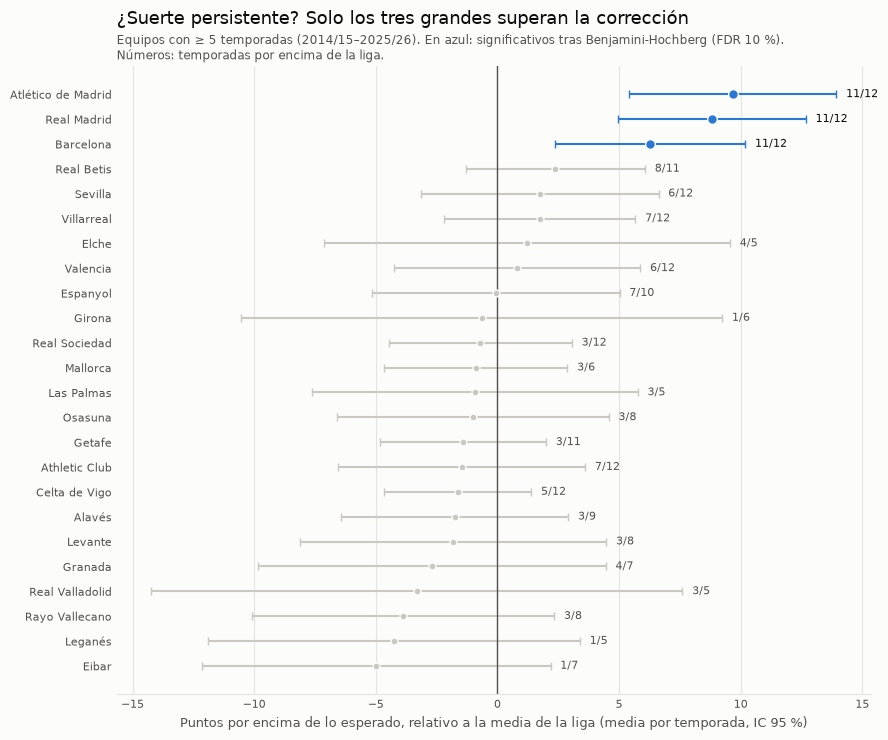

In [20]:
pts = pruebas[pruebas.medida == "puntos"].copy()
ic = relativa.groupby("equipo").suerte_puntos.agg(["mean", "std", "count"])
ic["margen"] = stats.t.ppf(0.975, ic["count"] - 1) * ic["std"] / np.sqrt(ic["count"])
pts = pts.merge(ic, left_on="equipo", right_index=True).sort_values("mean")

fig, ax = plt.subplots(figsize=(9, 7.5), facecolor=FONDO)
for i, (_, f) in enumerate(pts.iterrows()):
    significativo = f.q_BH < 0.10
    color = SERIE if significativo else GRIS
    ax.errorbar(f["mean"], i, xerr=f.margen, fmt="o", color=color, ecolor=color, markersize=7 if significativo else 5,
                markeredgecolor=FONDO, capsize=3, linewidth=1.5)
    ax.text(f["mean"] + f.margen + 0.4, i, f"{f.temporadas_por_encima_de_la_liga}/{f.temporadas}", va="center",
            fontsize=8, color=TINTA if significativo else TINTA_2)
ax.set_yticks(range(len(pts)), pts.equipo, fontsize=9, color=TINTA)
ax.axvline(0, color=TINTA_2, linewidth=1)
ax.set_xlabel("Puntos por encima de lo esperado, relativo a la media de la liga (media por temporada, IC 95 %)",
              color=TINTA_2, fontsize=9)
ax.set_facecolor(FONDO)
ax.grid(axis="x", color=REJILLA, linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors=TINTA_2, labelsize=8, length=0)
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)
ax.spines["bottom"].set_color(REJILLA)
ax.set_title("¿Suerte persistente? Solo los tres grandes superan la corrección", loc="left", fontsize=13, color=TINTA, pad=30)
ax.text(0, 1.01, "Equipos con ≥ 5 temporadas (2014/15–2025/26). En azul: significativos tras Benjamini-Hochberg (FDR 10 %).\n"
        "Números: temporadas por encima de la liga.", transform=ax.transAxes, fontsize=8.5, color=TINTA_2)
fig.tight_layout()
fig.savefig(FIGURES / "05_suerte_persistente.png", dpi=150, facecolor=FONDO)
plt.show()

## 7. Partidos anómalos: *Isolation Forest*

**Cómo funciona:** el algoritmo divide los datos al azar una y otra vez (elige una variable y un punto de corte). Un partido normal está rodeado de muchos parecidos y hacen falta muchos cortes para aislarlo; uno raro se aísla con pocos. La **puntuación de anomalía** mide lo fácil que es aislarlo: cuanto más baja, más raro.

A diferencia del rango intercuartílico de la fase 1 (una variable cada vez), detecta **combinaciones** raras aunque cada valor por separado sea normal.

**Observación:** un partido (2014/15–2025/26), con 18 variables: tiros, tiros a puerta, córners, faltas, amarillas, rojas, xG, pases profundos y acciones defensivas del PPDA de cada equipo. Se usan las acciones y no el ratio del PPDA, que se dispara con denominadores pequeños.

**Sin umbral:** se ordenan todos los partidos por su puntuación y se revisan los 20 primeros. Se comprueba que el ranking es estable con distintas semillas aleatorias.

In [21]:
from sklearn.ensemble import IsolationForest

BASE = ["tiros", "tiros_puerta", "corners", "faltas", "amarillas", "rojas", "xg", "pases_profundos", "ppda_acciones"]
COLS = [f"{b}_{s}" for s in ("local", "visitante") for b in BASE]
an = con.sql("SELECT * FROM partidos WHERE temporada >= '2014-15'").df()
assert an[COLS].notna().all().all()

def puntuar(semilla):
    bosque = IsolationForest(n_estimators=500, random_state=semilla).fit(an[COLS])
    return bosque.score_samples(an[COLS])          # más bajo = más anómalo

an["anomalia"] = -puntuar(0)                        # signo cambiado: más alto = más anómalo
an["ranking"] = an.anomalia.rank(ascending=False).astype(int)

top20 = set(an.nsmallest(20, "ranking").id_partido)
solapes = [len(top20 & set(an.assign(s=-puntuar(sem)).nlargest(20, "s").id_partido)) for sem in (1, 2, 3, 4)]
print(f"{len(an)} partidos · coincidencia del top 20 con otras 4 semillas: {solapes} de 20")

4560 partidos · coincidencia del top 20 con otras 4 semillas: [17, 18, 18, 17] de 20


In [22]:
# ¿Por qué es raro cada uno? Variables con valor extremo (|z| > 2,5 respecto a todos los partidos)
z = (an[COLS] - an[COLS].mean()) / an[COLS].std()

def motivo(i):
    extremas = z.loc[i][z.loc[i].abs() > 2.5].sort_values(key=abs, ascending=False)
    return ", ".join(f"{c.replace('_local', ' (L)').replace('_visitante', ' (V)')} {an.loc[i, c]:g}" for c in extremas.index[:4])

top = an.nsmallest(20, "ranking").copy()
top["partido"] = top.local + " " + top.goles_local.astype(str) + "–" + top.goles_visitante.astype(str) + " " + top.visitante
top["fecha"] = top.fecha.dt.strftime("%d/%m/%Y")
top["variables extremas"] = [motivo(i) for i in top.index]
top[["ranking", "temporada", "fecha", "partido", "variables extremas"]].reset_index(drop=True)

,ranking,temporada,fecha,partido,variables extremas
0,1,2024-25,02/03/2025,Barcelona 4–0 Real Sociedad,"pases_profundos (L) 33, tiros (L) 33"
1,2,2022-23,28/05/2023,Barcelona 3–0 Mallorca,"pases_profundos (L) 26, xg (L) 4.40817, corner..."
2,3,2022-23,14/08/2022,Almería 1–2 Real Madrid,"tiros_puerta (V) 15, corners (V) 15, tiros (V)..."
3,4,2020-21,31/10/2020,Alavés 1–1 Barcelona,"pases_profundos (V) 24, corners (V) 14, tiros ..."
4,5,2014-15,02/05/2015,Córdoba 0–8 Barcelona,"xg (V) 6.18696, pases_profundos (V) 23, tiros ..."
5,6,2022-23,22/10/2022,Rayo Vallecano 5–1 Cádiz,"rojas (V) 2, tiros (L) 28, rojas (L) 1, xg (L)..."
6,7,2022-23,15/04/2023,Cádiz 0–2 Real Madrid,"pases_profundos (V) 28, tiros (V) 35, xg (V) 4..."
7,8,2015-16,29/11/2015,Sevilla 1–0 Valencia,"rojas (V) 2, corners (L) 17, faltas (L) 26"
8,9,2022-23,06/11/2022,Real Betis 1–1 Sevilla,"rojas (L) 2, tiros (V) 22"
9,10,2025-26,16/08/2025,Mallorca 0–3 Barcelona,"rojas (L) 2, pases_profundos (V) 19, tiros (V) 24"


### Comprobación: ¿dónde quedan las faltas sospechosas de la fase 1?

En la fase 1 marcamos como sospechosos 9 casos de equipos con 0-2 faltas en un partido (posibles errores de transcripción, sin prueba). Si fueran errores groseros, el partido debería aparecer como anómalo en el conjunto de sus estadísticas.

In [23]:
sospechosos = an[(an.faltas_local <= 2) | (an.faltas_visitante <= 2)].copy()
sospechosos["partido"] = sospechosos.local + " – " + sospechosos.visitante
sospechosos["percentil_de_anomalia"] = (100 * (1 - sospechosos.ranking / len(an))).round(1)
sospechosos[["temporada", "partido", "faltas_local", "faltas_visitante", "ranking", "percentil_de_anomalia"]] \
    .sort_values("ranking").reset_index(drop=True)

,temporada,partido,faltas_local,faltas_visitante,ranking,percentil_de_anomalia
0,2025-26,Real Madrid – Atlético de Madrid,2,15,196,95.7
1,2021-22,Barcelona – Rayo Vallecano,10,1,418,90.8
2,2020-21,Atlético de Madrid – Osasuna,2,13,442,90.3
3,2024-25,Real Madrid – Girona,1,7,479,89.5
4,2015-16,Celta de Vigo – Villarreal,9,2,1194,73.8
5,2017-18,Málaga – Real Sociedad,16,0,1537,66.3
6,2016-17,Athletic Club – Real Madrid,1,4,1600,64.9
7,2018-19,Atlético de Madrid – Huesca,1,14,2683,41.2


### Conclusiones: partidos anómalos

- **El ranking es estable:** 17-18 de los 20 partidos más anómalos se repiten con otras semillas aleatorias.
- **Los partidos más anómalos son de dos tipos:** **dominio extremo** (Barcelona 4–0 Real Sociedad con 33 tiros y 33 pases profundos; Córdoba 0–8 Barcelona; Real Madrid 10–2 Rayo) y **partidos con varias expulsiones** (dos rojas a un equipo). Son partidos reales y excepcionales, no errores de datos.
- **Las faltas sospechosas de la fase 1 no son anomalías combinadas:** el más alto queda en el puesto 196 de 4.560 (percentil 96) y la mayoría por debajo del percentil 91. El resto de estadísticas de esos partidos es normal. No prueba que el dato de faltas sea correcto, pero no hay ninguna otra señal de error en esos partidos: se mantiene la decisión de conservarlos.
- **Diferencia con la fase 1:** el rango intercuartílico miraba una variable cada vez; el *Isolation Forest* encuentra **combinaciones** raras. Aquí ambos coinciden: lo raro en LaLiga son las goleadas con asedio y las expulsiones.

## 8. Exportación para Power BI

Mismo criterio que en la fase 4: los datos por equipo-temporada y por partido se exportan para agregarlos en Power BI; los resultados inferenciales (pruebas con corrección de Benjamini-Hochberg, correlaciones con IC) se exportan tal como se calcularon aquí.

| Fichero | Contenido | ¿En Git? |
|---|---|---|
| `suerte_equipo_temporada.csv` | Puntos, puntos esperados y suerte (puntos, ataque, defensa), absoluta y relativa a la media de la liga | No (derivado de Understat) |
| `suerte_persistente.csv` | Las 72 pruebas por equipo y medida, con IC 95 %, p y q de Benjamini-Hochberg | Sí (resumen agregado) |
| `suerte_persistencia_vueltas.csv` | Correlación 1ª-2ª vuelta de suerte y rendimiento, con IC 95 % | Sí (resumen agregado) |
| `sorpresas.csv` | Probabilidades de cada partido, equipo sorprendente y tipo de sorpresa | No (usa xG) |
| `partidos_anomalos.csv` | Puntuación y ranking del *Isolation Forest* y variables extremas de cada partido | No (usa xG, PPDA…) |

⚠️ **`sorpresas.csv` es descriptivo, no predictivo:** el modelo de la sección 5 se ajusta con todas las temporadas (probabilidades *dentro de muestra*). Además **no incluye** los 5 primeros partidos de cada ascendido ni los partidos sin forma en xG completa (inicio de 2014/15). Las predicciones fuera de muestra están en `modelo_predicciones.csv` (fase 4).

El análisis exploratorio de jugadores **no se exporta**: queda fuera del criterio fijado y en un informe esa advertencia se perdería.

In [24]:
def documentar(fichero, df, descripciones, fuente, disponible_desde, momento):
    """Sustituye en el diccionario de datos las filas de `fichero` por las de sus columnas actuales."""
    assert list(descripciones) == list(df.columns), f"{fichero}: columnas sin documentar o en otro orden"
    ruta = PROCESSED / "diccionario_datos.csv"
    diccionario = pd.read_csv(ruta)
    nuevas = pd.DataFrame([{"fichero": fichero, "columna": c, "tipo": str(df[c].dtype), "descripcion": d,
                            "fuente": fuente, "disponible_desde": disponible_desde,
                            "momento": momento(c) if callable(momento) else momento}
                           for c, d in descripciones.items()])
    pd.concat([diccionario[diccionario.fichero != fichero], nuevas]).to_csv(ruta, index=False, encoding="utf-8")

In [25]:
suerte_export = suerte.merge(
    relativa[["temporada", "equipo", "suerte_puntos", "suerte_ataque", "suerte_defensa"]].rename(
        columns=lambda c: c if c in ("temporada", "equipo") else f"{c}_vs_liga"),
    on=["temporada", "equipo"])
assert len(suerte_export) == 240

ic = relativa.melt(id_vars=["temporada", "equipo"], value_vars=["suerte_puntos", "suerte_ataque", "suerte_defensa"],
                   var_name="medida", value_name="valor")
ic["medida"] = ic.medida.str.replace("suerte_", "")
ic = ic.groupby(["equipo", "medida"]).valor.agg(["std", "count"]).reset_index()
suerte_persistente = pruebas.merge(ic, on=["equipo", "medida"])
margen = stats.t.ppf(0.975, suerte_persistente["count"] - 1) * suerte_persistente["std"] / np.sqrt(suerte_persistente["count"])
suerte_persistente["ic95_inferior"] = suerte_persistente.media_por_temporada - margen
suerte_persistente["ic95_superior"] = suerte_persistente.media_por_temporada + margen
suerte_persistente["persistente"] = suerte_persistente.q_BH < 0.10
suerte_persistente = suerte_persistente.rename(columns={"q_BH": "q_bh"})[
    ["equipo", "medida", "temporadas", "media_por_temporada", "ic95_inferior", "ic95_superior",
     "temporadas_por_encima_de_la_liga", "p", "q_bh", "persistente"]]
assert len(suerte_persistente) == 72 and suerte_persistente.persistente.sum() == len(persistentes)

suerte_persistencia_vueltas = persistencia.rename(columns={
    "correlación 1ª-2ª vuelta": "correlacion", "IC 95 % inferior": "ic95_inferior", "IC 95 % superior": "ic95_superior"})

sorpresas = pm[["id_partido", "p_local", "p_empate", "p_visitante", "p_resultado",
                "equipo_sorprendente", "xg_dif_sorprendente", "tipo_sorpresa"]].copy()
sorpresas["equipo_sorprendente"] = sorpresas.equipo_sorprendente.replace("(empate)", pd.NA)
sorpresas["gran_sorpresa"] = sorpresas.p_resultado < 0.15

anomalos = an[["id_partido", "anomalia", "ranking"]].copy()
anomalos["percentil"] = 100 * (1 - anomalos.ranking / len(an))
anomalos["variables_extremas"] = [motivo(i) for i in an.index]
anomalos = anomalos.sort_values("ranking").reset_index(drop=True)

suerte_persistente[suerte_persistente.persistente].round(3)

,equipo,medida,temporadas,media_por_temporada,ic95_inferior,ic95_superior,temporadas_por_encima_de_la_liga,p,q_bh,persistente
0,Real Madrid,puntos,12,8.808,4.938,12.677,11,0.000,0.015,True
1,Atlético de Madrid,puntos,12,9.673,5.413,13.933,11,0.000,0.015,True
2,Real Madrid,defensa,12,5.366,2.370,8.362,10,0.002,0.055,True
3,Barcelona,puntos,12,6.268,2.348,10.187,11,0.005,0.086,True


In [26]:
MOMENTO_FIN = "se conoce al final de la temporada (descriptivo)"
DESC_SUERTE = {
    "temporada": "Temporada", "equipo": "Equipo", "partidos": "Partidos jugados", "puntos": "Puntos reales",
    "puntos_esperados": "Puntos esperados según el xG (Understat), redondeado a 1 decimal",
    "suerte_puntos": "Puntos reales − puntos esperados",
    "suerte_ataque": "Goles a favor − xG a favor (+ = marcó más de lo esperado)",
    "suerte_defensa": "xG en contra − goles en contra (+ = encajó menos de lo esperado)",
    "suerte_puntos_vs_liga": "Suerte en puntos menos la media de la liga esa temporada",
    "suerte_ataque_vs_liga": "Suerte en ataque menos la media de la liga esa temporada",
    "suerte_defensa_vs_liga": "Suerte en defensa menos la media de la liga esa temporada",
}
DESC_PERSISTENTE = {
    "equipo": "Equipo (con 5 temporadas o más en 2014/15–2025/26)", "medida": "puntos, ataque o defensa",
    "temporadas": "Temporadas del equipo", "media_por_temporada": "Media de la suerte relativa a la liga por temporada",
    "ic95_inferior": "Límite inferior del IC 95 % de la media (t de Student)", "ic95_superior": "Límite superior del IC 95 %",
    "temporadas_por_encima_de_la_liga": "Temporadas con suerte por encima de la media de la liga",
    "p": "p-valor de la prueba t (media = 0)",
    "q_bh": "p corregido por comparaciones múltiples (Benjamini-Hochberg, 72 pruebas)",
    "persistente": "True si q_bh < 0,10 (criterio fijado antes de mirar)",
}
DESC_VUELTAS = {
    "medida": "Medida comparada entre la 1ª y la 2ª vuelta", "tipo": "suerte (no debería repetirse) o rendimiento",
    "correlacion": "Correlación entre la 1ª y la 2ª vuelta del mismo equipo-temporada (240 pares)",
    "ic95_inferior": "Límite inferior del IC 95 % (transformación de Fisher)", "ic95_superior": "Límite superior del IC 95 %",
}
DESC_SORPRESAS = {
    "id_partido": "Identificador del partido (enlaza con partidos.csv)",
    "p_local": "Probabilidad de victoria local (modelo Elo + forma ajustado con todas las temporadas: dentro de muestra)",
    "p_empate": "Probabilidad de empate (dentro de muestra)", "p_visitante": "Probabilidad de victoria visitante (dentro de muestra)",
    "p_resultado": "Probabilidad que el modelo daba al resultado que ocurrió (menor = más sorprendente)",
    "equipo_sorprendente": "Equipo que ganó (vacío si fue empate)",
    "xg_dif_sorprendente": "xG del ganador − xG del perdedor (vacío si fue empate)",
    "tipo_sorpresa": "merecida (creó más xG) / con suerte (creó menos xG) / empate",
    "gran_sorpresa": "True si p_resultado < 0,15",
}
DESC_ANOMALOS = {
    "id_partido": "Identificador del partido (enlaza con partidos.csv)",
    "anomalia": "Puntuación de anomalía del Isolation Forest (mayor = más raro; 18 estadísticas del partido)",
    "ranking": "Posición de 1 (más anómalo) a 4.560",
    "percentil": "Percentil de anomalía (100 = el más raro)",
    "variables_extremas": "Hasta 4 estadísticas con |z| > 2,5 (L = local, V = visitante)",
}

for fichero, df, desc, fuente, momento in (
        ("suerte_equipo_temporada.csv", suerte_export, DESC_SUERTE, "Understat + calculado", MOMENTO_FIN),
        ("suerte_persistente.csv", suerte_persistente, DESC_PERSISTENTE, "Understat + calculado", MOMENTO_FIN),
        ("suerte_persistencia_vueltas.csv", suerte_persistencia_vueltas, DESC_VUELTAS, "Understat + calculado", MOMENTO_FIN),
        ("sorpresas.csv", sorpresas, DESC_SORPRESAS, "Calculado (modelo de la fase 5) + Understat",
         "después del partido (descriptivo: probabilidades dentro de muestra)"),
        ("partidos_anomalos.csv", anomalos, DESC_ANOMALOS, "football-data.co.uk + Understat + calculado", "después del partido")):
    df.to_csv(PROCESSED / fichero, index=False, encoding="utf-8")
    documentar(fichero, df, desc, fuente, "2014-15", momento)
    print(f"{fichero}: {len(df)} filas")

suerte_equipo_temporada.csv: 240 filas
suerte_persistente.csv: 72 filas
suerte_persistencia_vueltas.csv: 6 filas
sorpresas.csv: 4355 filas
partidos_anomalos.csv: 4560 filas


## Resumen de la fase 5

- **La suerte existe y es grande:** hasta ±20 puntos en una temporada (Atlético 2020/21 +19,6; Deportivo 2017/18 −20,2).
- **La mayor parte es azar:** se repite muy poco de una vuelta a otra (0,16), mientras que el rendimiento se repite mucho (0,62–0,82). Y se devuelve: por cada punto de suerte, 0,73 puntos menos al año siguiente (con sesgo de supervivencia: los desafortunados descienden más).
- **Lo persistente es de los grandes:** Real Madrid, Atlético y Barcelona superan sus puntos esperados casi todos los años. Sugiere que los puntos esperados infravaloran a la élite. No parece venir de la definición del equipo en conjunto (que coincide con su xG); las hipótesis (no verificadas) son la defensa y la gestión del marcador.
- **Historias atractivas que no resisten la prueba:** el Atlético encajando menos gracias a Oblak no supera la corrección por comparaciones múltiples.
- **Las mayores sorpresas** son derrotas en casa de los grandes; la mayoría, con suerte (el ganador creó menos xG). Y ocurren con la frecuencia que el modelo predice.
- **Partidos anómalos:** goleadas con asedio y expulsiones. Ningún indicio de errores de datos.